# IMPORTACIÓN DE LIBRERÍAS


In [108]:
# IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

# CARGA DEL DATASET


In [109]:
# CARGA DEL DATASET

# Cargamos el archivo CSV desde la carpeta Data
df = pd.read_csv("../Data/cleaned_tourist_accommodation_27_04.csv")

# EXPLORACIÓN DEL DATASET


In [110]:
# EXPLORACIÓN DEL DATASET

# Mostramos las primeras filas para entender la estructura
df.head(5)

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,review_scores_rating_clean,price_imputed
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2.0,1.0,...,100.0,100.0,100.0,FALSO,75.0,spain,malaga,31/07/2018,97.0,400.0
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,...,100.0,80.0,90.0,FALSO,52.0,spain,madrid,10/01/2020,92.0,170.0
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,...,100.0,100.0,100.0,VERDADERO,142.0,spain,sevilla,29/07/2019,98.0,990.0
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,...,100.0,100.0,90.0,VERDADERO,306.0,spain,barcelona,10/01/2020,94.0,400.0
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1.0,2.0,...,100.0,100.0,100.0,FALSO,39.0,spain,girona,19/02/2019,97.0,900.0


In [111]:
# Revisamos las columnas disponibles
df.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date', 'review_scores_rating_clean',
       'price_imputed'],
      dtype='object')

# LIMPIEZA

## limpiamos amenities_list

In [112]:
df["amenities_clean"] = df["amenities_list"].str.lower()

In [113]:
df["pool"] = df["amenities_clean"].str.contains("pool", na=False).astype(int)

df["hot_tub"] = df["amenities_clean"].str.contains(
    "hot tub|jacuzzi", na=False
).astype(int)

df["parking"] = df["amenities_clean"].str.contains(
    "parking", na=False
).astype(int)

df["air_conditioning"] = df["amenities_clean"].str.contains(
    "air conditioning|ac", na=False
).astype(int)

In [114]:
df.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date', 'review_scores_rating_clean',
       'price_imputed', 'amenities_clean', 'pool', 'hot_tub', 'parking',
       'air_conditioning'],
      dtype='object')

# ANALISI

## INTRO

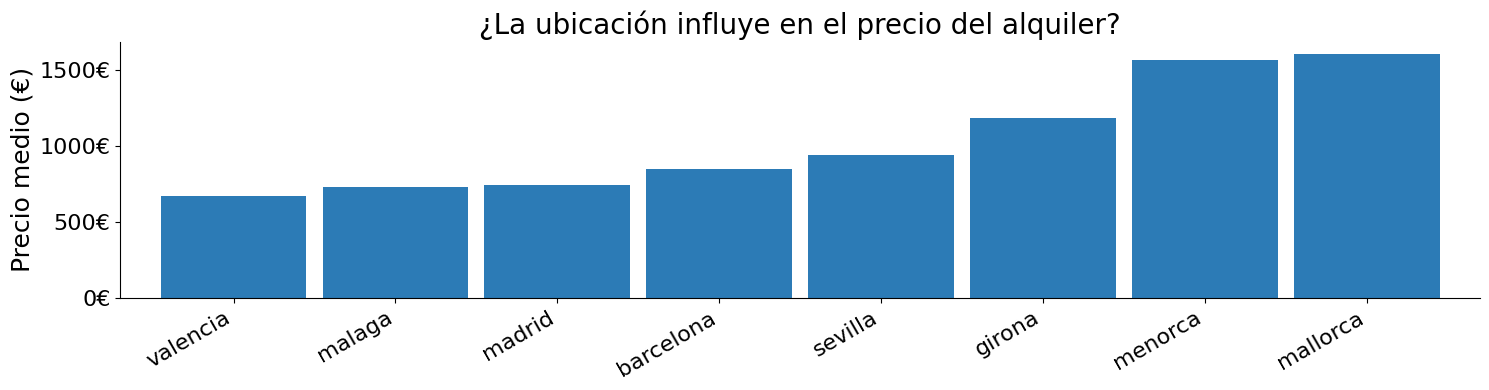

In [140]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# precio medio por ciudad

ax = df.groupby("city")["price_imputed"].mean().sort_values().plot(
    kind="bar",
    figsize=(15, 4),
    width=0.9,
    color="#2C7BB6"
)

# 👇 titolo più grande
ax.set_title("¿La ubicación influye en el precio del alquiler?", fontsize=20)

# 👇 label asse Y
ax.set_ylabel("Precio medio (€)", fontsize=18)

# 👇 niente label asse X
ax.set_xlabel("")

# 👇 dimensione nomi città
plt.xticks(rotation=30, ha="right", fontsize=16)

# 👇 dimensione numeri asse Y + €
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{int(x)}€')
)
ax.tick_params(axis='y', labelsize=16)

# 👇 pulizia grafica
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### storytelling: ya sabemos que el precio cambia mucho de ciutad en ciutad. Pero quales son las variables que mas impactan?

#### 1. Como impacta en el precio la capacidad de los alojamento?

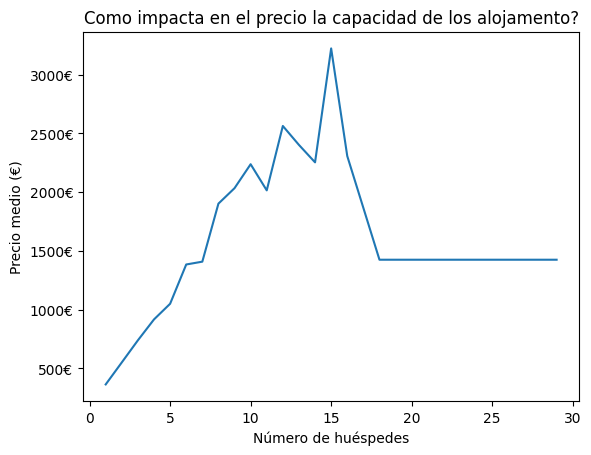

In [165]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df.groupby("accommodates")["price_imputed"].mean().plot(kind="line")

plt.title("Como impacta en el precio la capacidad de los alojamento?")
plt.xlabel("Número de huéspedes")
plt.ylabel("Precio medio (€)")

# 👇 aggiunge € ai valori dell’asse Y
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x)}€'))

plt.show()

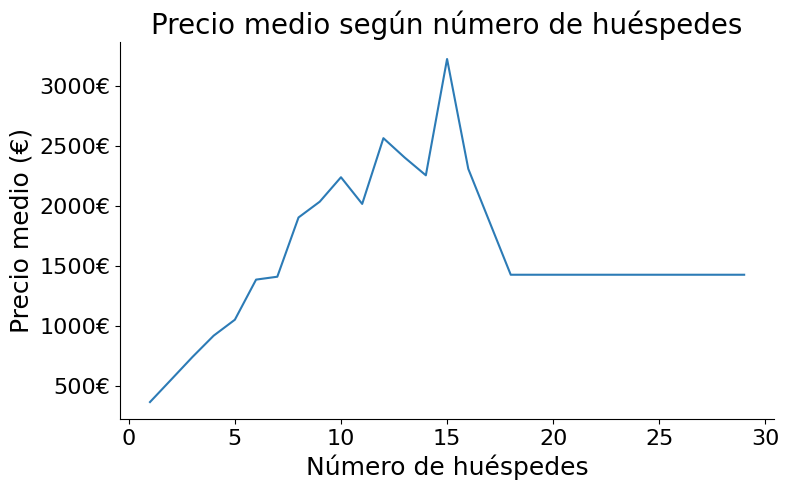

In [155]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# grafico

ax = df.groupby("accommodates")["price_imputed"].mean().plot(
    kind="line",
    figsize=(8,5),
    color="#2C7BB6"
    # 👇 niente marker
)

# 👇 titolo
ax.set_title("Precio medio según número de huéspedes", fontsize=20)

# 👇 assi
ax.set_xlabel("Número de huéspedes", fontsize=18)
ax.set_ylabel("Precio medio (€)", fontsize=18)

# 👇 formato € asse Y
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{int(x)}€')
)

# 👇 dimensione numeri
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# 👇 pulizia grafica
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### 2. Como impactan en el precio los servicios más solicitados por los huespedes?
[(fuente: Airbnb)](https://www.airbnb.com.ar/resources/hosting-homes/a/los-servicios-que-quieren-los-huspedes-25)

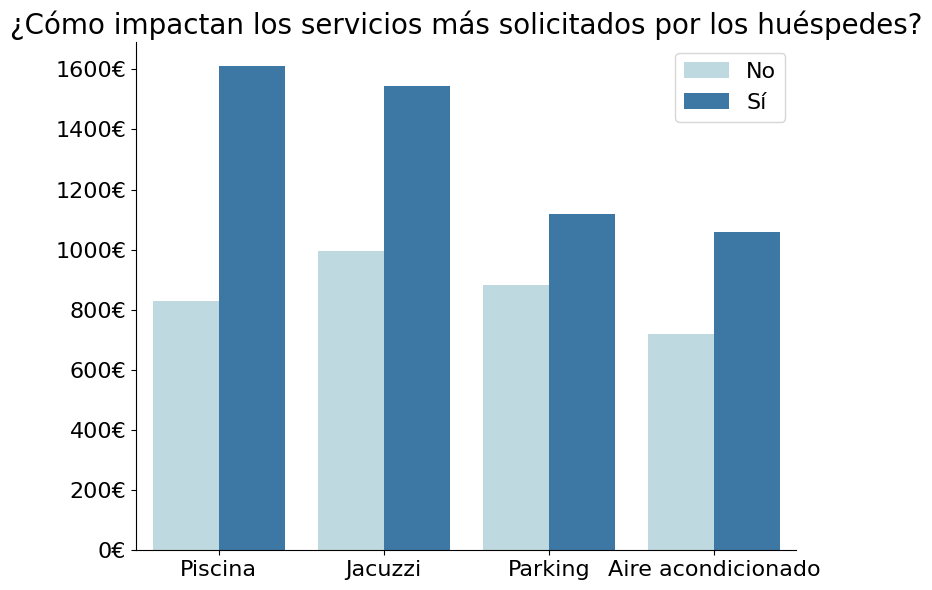

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=df_plot,
    x="amenity",
    y="precio_medio",
    hue="presencia",
    palette=["#B8DDE4", "#2C7BB6"]
)

# 👇 titolo
ax.set_title(
    "¿Cómo impactan los servicios más solicitados por los huéspedes?",
    fontsize=20
)

# 👇 assi (vuoti ma manteniamo font coerente)
ax.set_xlabel("", fontsize=18)
ax.set_ylabel("", fontsize=18)

# 👇 formato € asse Y
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{int(x)}€')
)

# 👇 dimensione numeri
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# 👇 legenda coerente
plt.legend(title="", fontsize=16)

# 👇 pulizia grafica
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### Storytelling: para saber qual variable influye mas y cuanto (en euro) hacemos una regresion:

## REGRESIÓN CON RANDOM FOREST
Nos dice qué variable influye más en el precio (pero no nos dice cuánto en términos de euros)

In [118]:
# Import librerie
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [119]:
# PREPARACIÓN DEL DATASET

features = [
    "accommodates",
    "pool",
    "hot_tub",
    "parking",
    "air_conditioning"
]

target = "price_imputed"

df_rf = df[
    ["city", target] + features
].dropna()

# Diccionario para mostrar nombres en castellano
features_es = {
    "accommodates": "Número de huéspedes",
    "pool": "Piscina",
    "hot_tub": "Jacuzzi",
    "parking": "Parking",
    "air_conditioning": "Aire acondicionado"
}

In [120]:
# RANDOM FOREST GENERAL
# Un valor más alto = más importante

X = df_rf[features]
y = df_rf[target]

rf_general = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_general.fit(X, y)

# Importancia variables general
rf_general_importance = (
    pd.Series(rf_general.feature_importances_, index=features)
    .rename(index=features_es)
    .sort_values(ascending=False)
)

rf_general_importance

Número de huéspedes    0.876188
Piscina                0.065018
Aire acondicionado     0.025171
Parking                0.021498
Jacuzzi                0.012125
dtype: float64

Insight: Ya se vee que accomodates influye mucho mas que las otras variables.

In [121]:
# RANDOM FOREST POR CIUDAD

rf_results = {}

for city in df_rf["city"].unique():
    
    df_city = df_rf[df_rf["city"] == city].copy()
    
    X_city = df_city[features]
    y_city = df_city[target]
    
    rf_city = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
    
    rf_city.fit(X_city, y_city)
    
    rf_results[city] = pd.Series(
        rf_city.feature_importances_,
        index=features
    )

# Tabla ciudad x variables
rf_city_df = pd.DataFrame(rf_results).T

# 👇 Renombramos columnas en castellano
rf_city_df = rf_city_df.rename(columns=features_es)

# Tabla coloreada
rf_city_df.style.background_gradient(cmap="Blues", axis=None)

,Número de huéspedes,Piscina,Jacuzzi,Parking,Aire acondicionado
malaga,0.651548,0.151528,0.029237,0.068502,0.099185
madrid,0.823026,0.030078,0.019331,0.100364,0.027201
sevilla,0.734532,0.097552,0.013000,0.093440,0.061476
barcelona,0.893157,0.027506,0.022686,0.029234,0.027417
girona,0.737754,0.099587,0.037267,0.057966,0.067426
valencia,0.830977,0.030933,0.032177,0.069754,0.036158
mallorca,0.780559,0.105668,0.029264,0.043619,0.040890
menorca,0.775580,0.076219,0.025427,0.058469,0.064304


Insight: Para todas las ciudades, accommodates influye más en el precio.

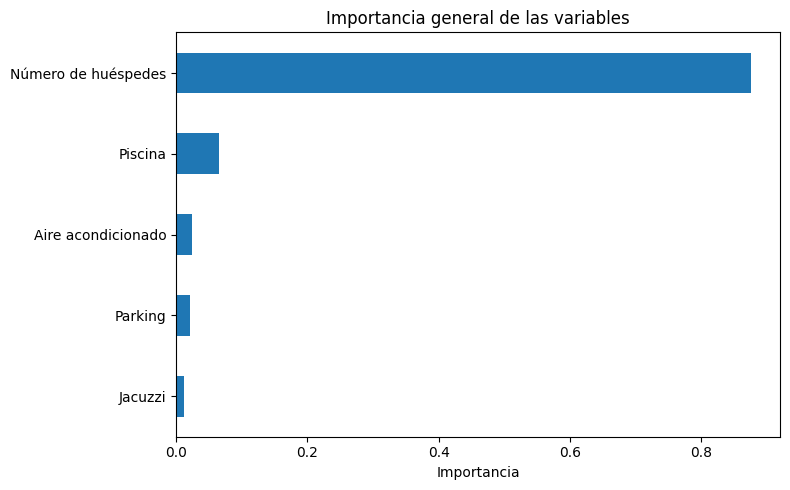

In [122]:
# GRÁFICO GENERAL

rf_general_importance.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Importancia general de las variables")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

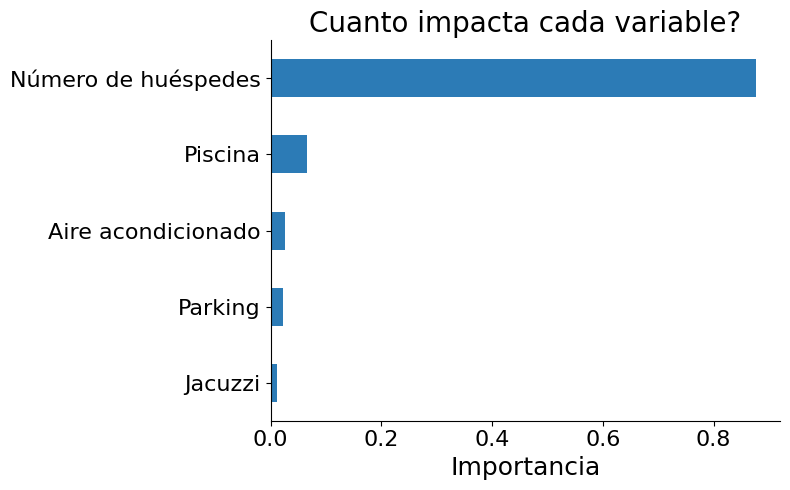

In [157]:
import matplotlib.pyplot as plt

# GRÁFICO GENERAL

ax = rf_general_importance.sort_values().plot(
    kind="barh",
    figsize=(8,5),
    color="#2C7BB6"
)

# 👇 titolo
ax.set_title("Cuanto impacta cada variable?", fontsize=20)

# 👇 assi
ax.set_xlabel("Importancia", fontsize=18)
ax.set_ylabel("", fontsize=18)

# 👇 dimensione numeri
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# 👇 pulizia grafica
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

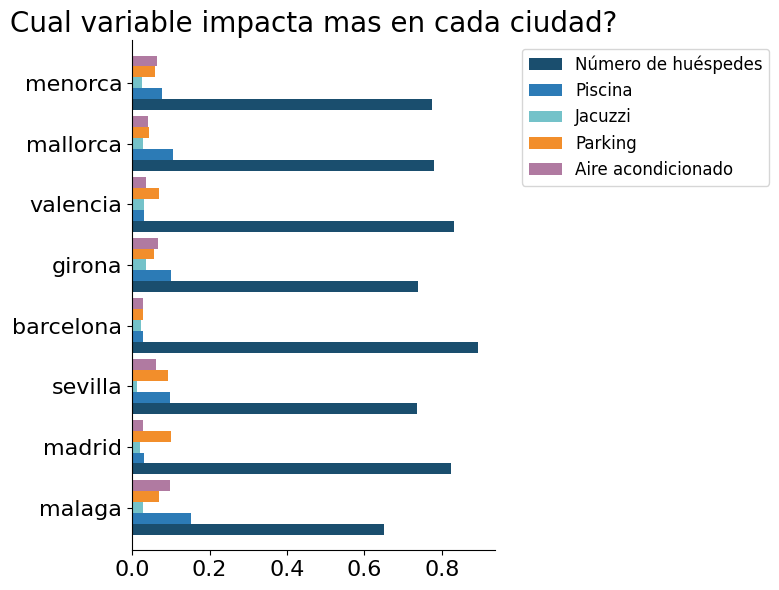

In [160]:
# GRÁFICO POR CIUDAD

colors = [
    "#1A4E6E",  # Número de huéspedes
    "#2C7BB6",  # Piscina
    "#74C2C9",  # Jacuzzi
    "#F28E2B",  # Parking
    "#B07AA1"   # Aire acondicionado
]

ax = rf_city_df.plot(
    kind="barh",
    figsize=(8,6),
    color=colors,
    width=0.9  # 👈 barre più larghe
)

# 👇 titolo
ax.set_title("Cual variable impacta mas en cada ciudad?", fontsize=20)

# 👇 assi puliti
ax.set_xlabel("", fontsize=18)
ax.set_ylabel("", fontsize=18)

# 👇 dimensione numeri
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# 👇 legenda più piccola
plt.legend(
    title="",
    fontsize=12,  # 👈 ridotta
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# 👇 pulizia grafica
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

_____________

## REGRESIÓN LINEAL
Nos dice también CUANTO cambia el precio en función de la variable

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [125]:
features = ["accommodates", "pool", "hot_tub", "parking", "air_conditioning"]
target = "price_imputed"

df_lin = df[["city", target] + features].dropna()

# Diccionario nombres en castellano
features_es = {
    "accommodates": "Número de huéspedes",
    "pool": "Piscina",
    "hot_tub": "Jacuzzi",
    "parking": "Parking",
    "air_conditioning": "Aire acondicionado"
}

In [126]:
# REGRESIÓN GENERAL

model_general = smf.ols(
    formula="price_imputed ~ accommodates + pool + hot_tub + parking + air_conditioning",
    data=df_lin
).fit()

coef_general = (
    model_general.params
    .drop("Intercept")
    .rename(index=features_es)  # 👈 traducción aquí
)



coef_general_formatted = coef_general.apply(lambda x: f"{int(x)}€")

coef_general_formatted

Número de huéspedes    165€
Piscina                353€
Jacuzzi                 95€
Parking                -46€
Aire acondicionado     138€
dtype: object

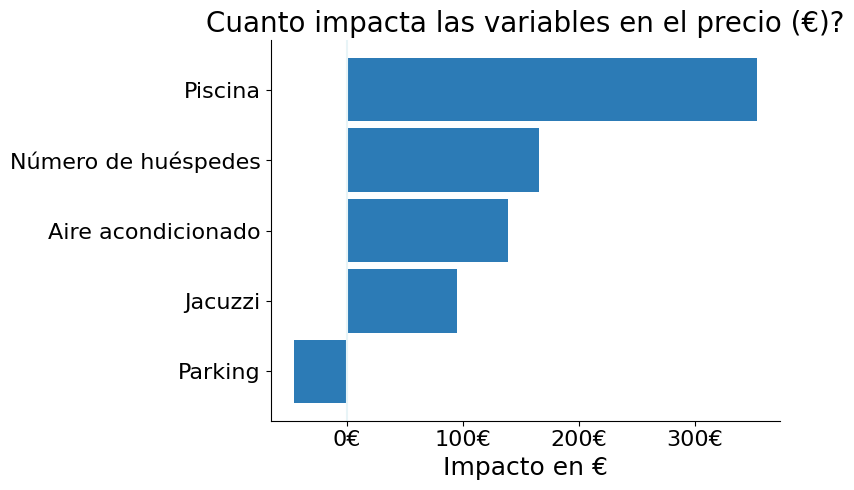

In [162]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# VISUALIZACIÓN GENERAL

ax = coef_general.sort_values().plot(
    kind="barh",
    figsize=(8,5),
    width=0.9,           # 👈 barre più larghe
    color="#2C7BB6"      # 👈 colore coerente
)

# 👇 titolo
ax.set_title("Cuanto impacta las variables en el precio (€)?", fontsize=20)

# 👇 asse X
ax.set_xlabel("Impacto en €", fontsize=18)
ax.set_ylabel("")

# 👇 € sull’asse X
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{int(x)}€')
)

# 👇 dimensione numeri
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# 👇 linea zero (più elegante)
ax.axvline(0, color="#E8F4F7")

# 👇 pulizia grafica
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

____________

In [128]:
# REGRESIÓN POR CIUDAD

results = {}

for city in df_lin["city"].unique():
    
    df_city = df_lin[df_lin["city"] == city]
    
    model = smf.ols(
        formula="price_imputed ~ accommodates + pool + hot_tub + parking + air_conditioning",
        data=df_city
    ).fit()
    
    results[city] = model.params

In [129]:
# TABLA POR CIUDAD

coef_df = []

for city, coef in results.items():
    temp = coef.copy()
    temp["city"] = city
    coef_df.append(temp)

coef_df = pd.DataFrame(coef_df)

coef_df_clean = (
    coef_df
    .set_index("city")
    .rename_axis("Ciudad")
    .drop(columns=["Intercept"], errors="ignore")
    .rename(columns=features_es)
    .round(0)          # arrotonda
    .astype(int)       # elimina .0
)


In [130]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "custom",
    ["#C73E1D", "#F5F5F5", "#2C7BB6"]  # rosso → bianco → blu
)

coef_df_clean.style.format("{:.0f}€").background_gradient(
    cmap=cmap,
    axis=None,
    vmin=-coef_df_clean.abs().max().max(),
    vmax=coef_df_clean.abs().max().max()
)

,Número de huéspedes,Piscina,Jacuzzi,Parking,Aire acondicionado
Ciudad,,,,,
malaga,113€,241€,318€,-31€,17€
madrid,157€,146€,47€,-37€,64€
sevilla,153€,417€,119€,-112€,-16€
barcelona,196€,291€,54€,-52€,159€
girona,165€,257€,-132€,33€,222€
valencia,127€,10€,323€,-47€,6€
mallorca,134€,444€,235€,69€,22€
menorca,220€,283€,-4€,-271€,77€


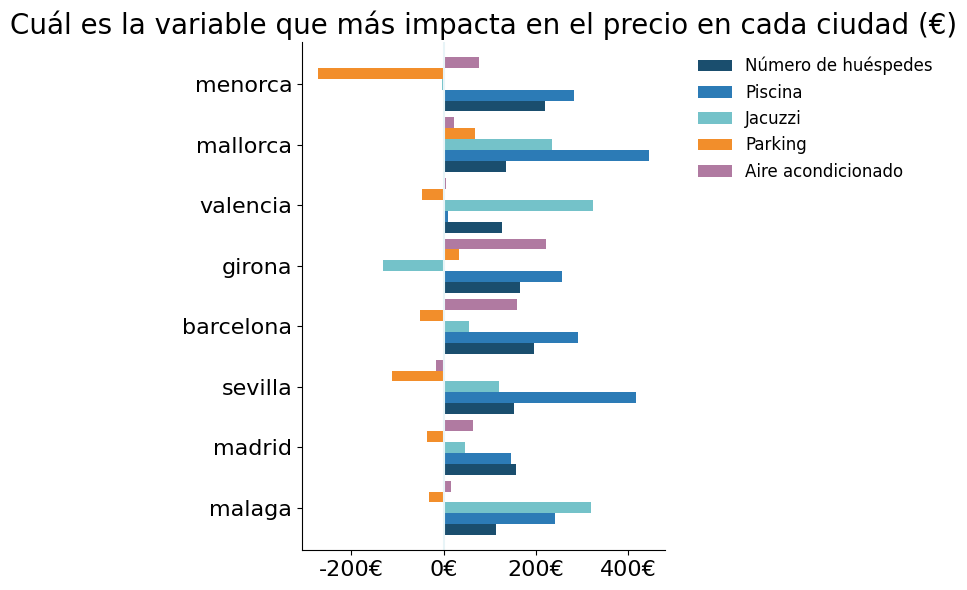

In [164]:
import matplotlib.ticker as mtick

# VISUALIZACIÓN POR CIUDAD

colors = [
    "#1A4E6E",  # Número de huéspedes
    "#2C7BB6",  # Piscina
    "#74C2C9",  # Jacuzzi
    "#F28E2B",  # Parking
    "#B07AA1"   # Aire acondicionado
]

ax = coef_df_clean.plot(
    kind="barh",
    figsize=(8,6),
    color=colors,
    width=0.9  # 👈 barre più larghe
)

# 👇 titolo
ax.set_title("Cuál es la variable que más impacta en el precio en cada ciudad (€)", fontsize=20)

# 👇 assi puliti
ax.set_xlabel("", fontsize=18)
ax.set_ylabel("", fontsize=18)

# 👇 € asse X
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{int(x)}€')
)

# 👇 dimensione numeri
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# 👇 linea zero
ax.axvline(0, color="#E8F4F7")

# 👇 legenda più discreta
plt.legend(
    title="",
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# 👇 pulizia grafica
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()